# PJM Energy Trends & Seasonality 

**Dataset:** PJM East (PJME) hourly electricity demand  
**Goal:** Explore temporal resolution, trend, seasonality, decomposition, and uncertainty.



In [16]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams["figure.figsize"] = (12, 4)


## 1. Locate the project and load processed data

In [17]:
cwd = Path.cwd()

if (cwd / "data" / "processed").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "processed").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate project root containing data/processed."
    )

DATA_DIR = PROJECT_ROOT / "data" / "processed"

print("Working directory:", cwd)
print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Data directory exists:", DATA_DIR.exists())


Working directory: /Users/nazi/Documents/Data_visual/HW_4/PJM-Energy-Trends-and-Seasonality/notebooks
Project root: /Users/nazi/Documents/Data_visual/HW_4/PJM-Energy-Trends-and-Seasonality
Data directory: /Users/nazi/Documents/Data_visual/HW_4/PJM-Energy-Trends-and-Seasonality/data/processed
Data directory exists: True


In [18]:
monthly = pd.read_csv(
    DATA_DIR / "PJME_monthly.csv",
    parse_dates=["Datetime"],
    index_col="Datetime"
)

daily = pd.read_csv(
    DATA_DIR / "PJME_daily.csv",
    parse_dates=["Datetime"],
    index_col="Datetime"
)

print("Monthly shape:", monthly.shape)
print("Monthly start:", monthly.index.min())
print("Monthly end:", monthly.index.max())

monthly.head()


Monthly shape: (200, 1)
Monthly start: 2002-01-01 00:00:00
Monthly end: 2018-08-01 00:00:00


,PJME_MW
Datetime,
2002-01-01,31075.399731
2002-02-01,30239.166667
2002-03-01,28875.256720
2002-04-01,28529.284028
2002-05-01,28073.653226


## 2. Use complete interior months for statistical analysis

In [19]:
# January 2002 begins at 01:00 rather than 00:00.
# August 2018 contains only the first few days.
# Exclude those incomplete boundary months from statistical analysis.

monthly_analysis = (
    monthly.loc["2002-02-01":"2018-07-01", "PJME_MW"]
    .dropna()
)

print("Analysis observations:", len(monthly_analysis))
print("Start:", monthly_analysis.index.min())
print("End:", monthly_analysis.index.max())
print(
    "Approximate span:",
    round(
        (monthly_analysis.index.max() - monthly_analysis.index.min()).days / 365.25,
        2
    ),
    "years"
)

monthly_analysis.head()


Analysis observations: 198
Start: 2002-02-01 00:00:00
End: 2018-07-01 00:00:00
Approximate span: 16.41 years


Datetime
2002-02-01    30239.166667
2002-03-01    28875.256720
2002-04-01    28529.284028
2002-05-01    28073.653226
2002-06-01    33585.919444
Name: PJME_MW, dtype: float64

## 3. Trend: monthly demand vs. 12-month rolling mean

In [20]:
rolling_12 = monthly_analysis.rolling(12).mean()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=monthly_analysis.index,
        y=monthly_analysis,
        mode="lines",
        name="Monthly mean demand",
        opacity=0.45,
        line=dict(width=1.4)
    )
)

fig.add_trace(
    go.Scatter(
        x=rolling_12.index,
        y=rolling_12,
        mode="lines",
        name="12-month rolling mean",
        line=dict(width=3)
    )
)

fig.update_layout(
    title="PJM East Electricity Demand: Monthly Variation and Long-Term Trend",
    xaxis_title="Date",
    yaxis_title="Average electricity demand (MW)",
    hovermode="x unified",
    template="plotly_white",
    height=520,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0
    )
)

fig.show()


### Interpretation — trend

The monthly PJME series shows a strong repeating seasonal cycle superimposed on a slower long-run change in electricity demand. The 12-month rolling mean removes most of the within-year oscillation and makes the underlying level easier to read: average demand rises from roughly 31.9 thousand MW in early 2003 to a rolling-mean peak of about 33.7 thousand MW around January 2008, then generally trends downward, reaching its lowest 12-month level of about 30.4 thousand MW in 2017 before ending near 31.2 thousand MW in July 2018. The raw monthly series therefore tells the seasonal story, while the 12-month mean is more appropriate for discussing the longer-run trend.

**Temporal-honesty note:** January 2002 and August 2018 are excluded from this statistical analysis because they are incomplete boundary months. Keeping them in the decomposition or seasonal comparisons could make those periods appear directly comparable to complete months when they are not.

## 4. Seasonality: ACF of differenced monthly demand

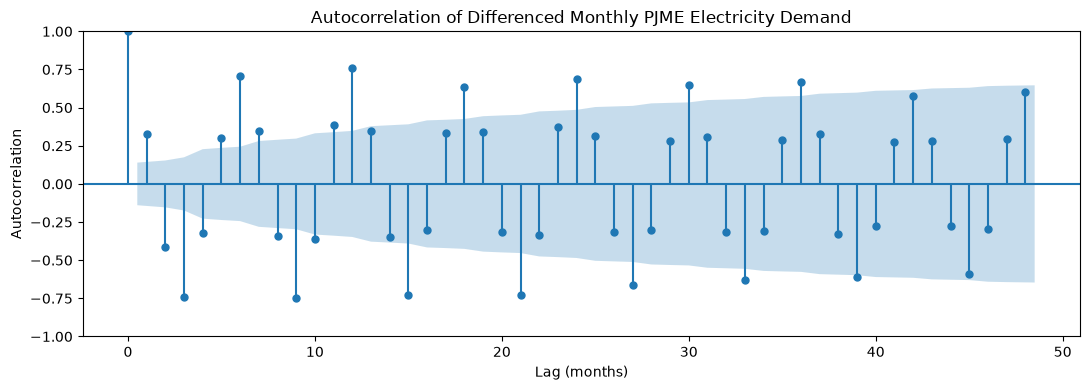

In [21]:
monthly_diff = monthly_analysis.diff().dropna()

fig, ax = plt.subplots(figsize=(11, 4))

plot_acf(
    monthly_diff,
    lags=48,
    ax=ax
)

ax.set_title(
    "Autocorrelation of Differenced Monthly PJME Electricity Demand"
)
ax.set_xlabel("Lag (months)")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()


### Interpretation — ACF and seasonal period

The ACF of the **differenced** monthly series shows a clear repeating structure. The strongest positive seasonal spike occurs at lag 12 (about 0.76), with additional positive spikes around 24, 36, and 48 months. This supports a dominant **12-month annual seasonal period**. Strong positive correlations also appear near 6, 18, 30, and 42 months, while negative correlations occur between them, indicating a pronounced semiannual harmonic inside the annual cycle.

Differencing is important here because it reduces the slower-moving trend before measuring autocorrelation. Without removing that trend, nearby observations could appear highly correlated simply because the overall demand level changes gradually over time, which would make the seasonal period harder to interpret.

## 5. Rolling-window comparison

In [22]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=monthly_analysis.index,
        y=monthly_analysis,
        mode="lines",
        name="Monthly demand",
        opacity=0.22,
        line=dict(width=1)
    )
)

for window in [3, 12, 60]:
    fig.add_trace(
        go.Scatter(
            x=monthly_analysis.index,
            y=monthly_analysis.rolling(window).mean(),
            mode="lines",
            name=f"{window}-month rolling mean"
        )
    )

fig.update_layout(
    title="How Rolling-Window Length Changes the PJME Demand Story",
    xaxis_title="Date",
    yaxis_title="Average electricity demand (MW)",
    hovermode="x unified",
    template="plotly_white",
    height=540
)

fig.show()


### Interpretation — rolling windows

The three rolling windows answer different temporal questions. The **3-month rolling mean** smooths only the shortest fluctuations, so it still follows most of the recurring seasonal peaks and troughs. The **12-month rolling mean** spans one complete annual cycle and therefore averages away much of the yearly seasonality, making medium- and long-run movement easier to see. The **60-month rolling mean** produces a very smooth five-year trajectory, but it suppresses shorter genuine changes and reacts slowly to turning points.

This comparison demonstrates why the rolling-window length must be disclosed: changing the window changes the story the viewer sees.

## 6. Month-of-year seasonal profile

In [23]:
import calendar

seasonal_profile = monthly_analysis.rename("PJME_MW").to_frame()
seasonal_profile["month_num"] = seasonal_profile.index.month

month_profile = (
    seasonal_profile
    .groupby("month_num")["PJME_MW"]
    .agg(["mean", "std", "count"])
)

month_profile["month"] = [
    calendar.month_abbr[m]
    for m in month_profile.index
]

month_profile


,mean,std,count,month
month_num,,,,
1,34547.212366,1396.578112,16,Jan
2,33439.527727,1997.921953,17,Feb
3,30510.017868,1298.197247,17,Mar
4,27861.419036,924.464333,17,Apr
5,28695.362113,1241.514609,17,May
6,33811.799183,1713.162769,17,Jun
7,37881.972881,1891.308408,17,Jul
8,36584.698253,2175.140793,16,Aug
9,31484.054688,1382.970379,16,Sep


In [24]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=month_profile["month"],
        y=month_profile["mean"],
        mode="lines+markers",
        name="Mean monthly demand",
        line=dict(width=3),
        marker=dict(size=8)
    )
)

fig.update_layout(
    title="Average PJME Electricity Demand by Month of Year",
    xaxis_title="Month",
    yaxis_title="Average electricity demand (MW)",
    template="plotly_white",
    height=480,
    hovermode="x unified"
)

fig.show()


### Interpretation — seasonal profile

The calendar-month profile confirms a strong and non-uniform annual cycle. Demand is lowest in spring, with **April averaging about 27.9 thousand MW**, then rises sharply through early summer and reaches its highest monthly average in **July at about 37.9 thousand MW**. A second elevated period appears in winter, especially **January at about 34.5 thousand MW** and February at about 33.4 thousand MW. Demand falls again in early autumn, with October averaging about 28.1 thousand MW.

The presence of both summer and winter high-demand periods explains the six-month harmonic visible in the ACF, while the repetition of the full pattern from year to year supports using **12 months** as the decomposition period.

## 7. Additive vs. multiplicative seasonal decomposition

In [25]:
PERIOD = 12

additive = seasonal_decompose(
    monthly_analysis,
    model="additive",
    period=PERIOD,
    extrapolate_trend="freq"
)

multiplicative = seasonal_decompose(
    monthly_analysis,
    model="multiplicative",
    period=PERIOD,
    extrapolate_trend="freq"
)


/var/folders/9g/2ht_6m3s2634n2n_qf3xjvd40000gn/T/ipykernel_21539/2025742252.py:3: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  additive = seasonal_decompose(
/var/folders/9g/2ht_6m3s2634n2n_qf3xjvd40000gn/T/ipykernel_21539/2025742252.py:10: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  multiplicative = seasonal_decompose(


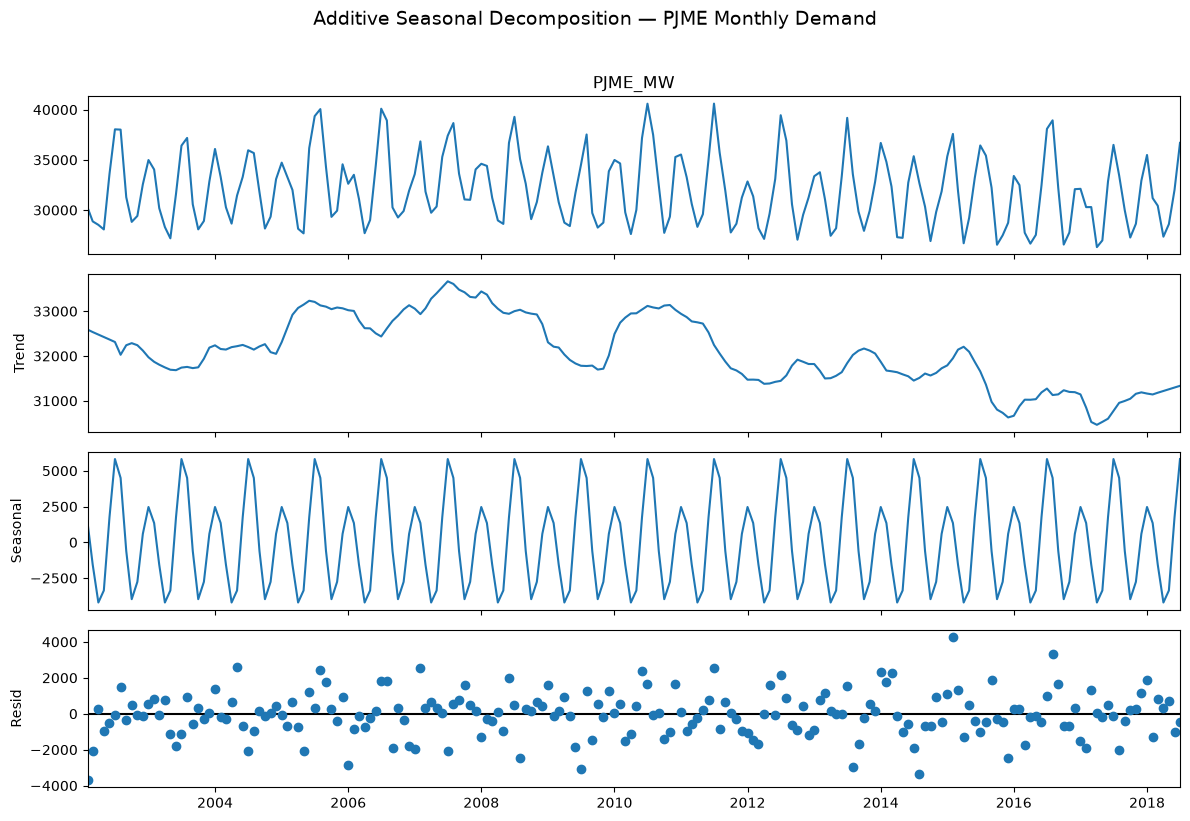

In [26]:
fig = additive.plot()
fig.set_size_inches(12, 8)
fig.suptitle(
    "Additive Seasonal Decomposition — PJME Monthly Demand",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()


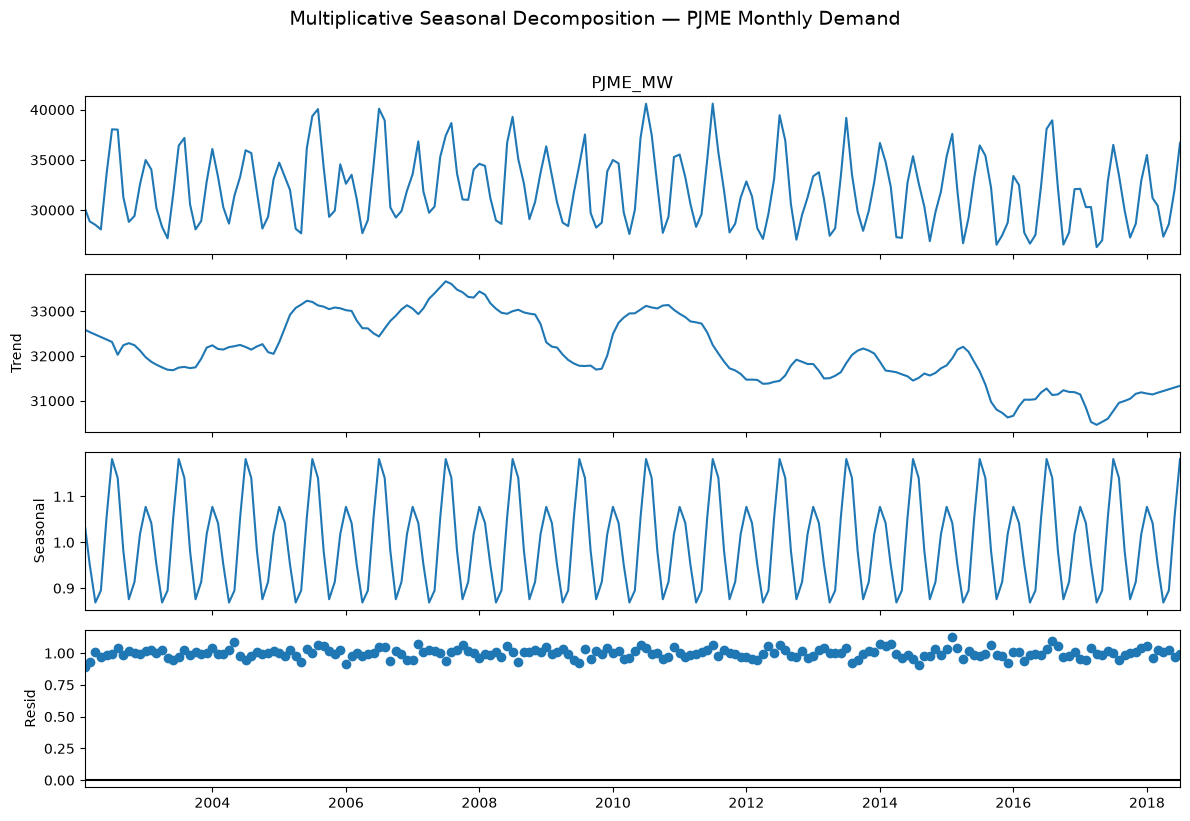

In [27]:
fig = multiplicative.plot()
fig.set_size_inches(12, 8)
fig.suptitle(
    "Multiplicative Seasonal Decomposition — PJME Monthly Demand",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()


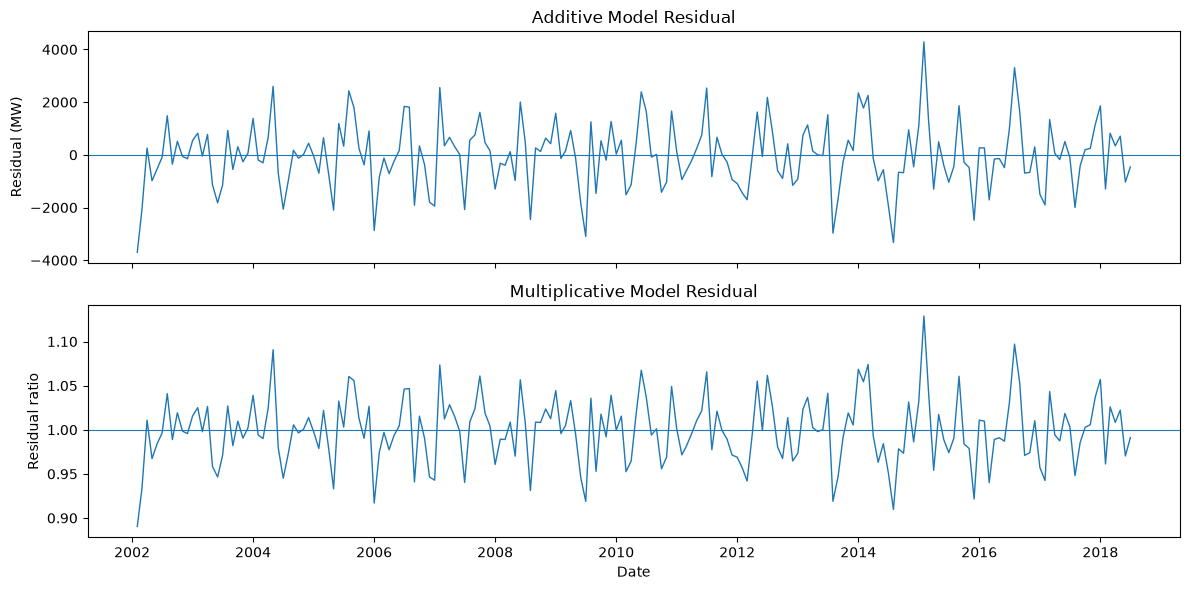

In [28]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 6),
    sharex=True
)

axes[0].plot(
    additive.resid.index,
    additive.resid,
    linewidth=1
)
axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("Additive Model Residual")
axes[0].set_ylabel("Residual (MW)")

axes[1].plot(
    multiplicative.resid.index,
    multiplicative.resid,
    linewidth=1
)
axes[1].axhline(1, linewidth=0.8)
axes[1].set_title("Multiplicative Model Residual")
axes[1].set_ylabel("Residual ratio")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()


### Interpretation — additive vs. multiplicative decomposition

Both decompositions capture the same broad trend and annual seasonal cycle, and their residual patterns are very similar, so the evidence does **not** show a dramatic difference between the two models. On the original MW scale, their reconstruction errors are nearly tied: the additive model has an RMSE of approximately **1,253.8 MW**, while the multiplicative model is approximately **1,252.5 MW**. The residual autocorrelation is also similar, with little remaining correlation at lag 12 in either model.

For this project, the **additive decomposition is the more interpretable choice**. The observed seasonal peak-to-trough amplitude varies across years but is not strongly proportional to the overall annual demand level, so representing seasonality as an approximately fixed number of MW is reasonable. The additive model also lets the seasonal and residual components be discussed directly in MW. Because the two models are so close, this choice should be described as a practical interpretation decision rather than evidence that the multiplicative model is incorrect.

## 8. Bootstrap uncertainty for the monthly mean

In [29]:
# Bootstrap the overall mean monthly demand.
# This is an uncertainty interval for an estimated statistic,
# not a prediction interval for individual observations.

rng = np.random.default_rng(42)
values = monthly_analysis.to_numpy()

B = 5000
boot_means = np.empty(B)

for i in range(B):
    sample = rng.choice(values, size=len(values), replace=True)
    boot_means[i] = sample.mean()

estimate = values.mean()
lo, hi = np.percentile(boot_means, [2.5, 97.5])

print(f"Mean monthly demand: {estimate:,.2f} MW")
print(f"95% bootstrap CI: [{lo:,.2f}, {hi:,.2f}] MW")


Mean monthly demand: 32,076.75 MW
95% bootstrap CI: [31,577.70, 32,567.74] MW


In [30]:
fig = go.Figure()

fig.add_trace(
    go.Histogram(
        x=boot_means,
        nbinsx=45,
        name="Bootstrap means",
        opacity=0.8
    )
)

fig.add_vline(
    x=lo,
    line_dash="dash",
    annotation_text="2.5%"
)

fig.add_vline(
    x=hi,
    line_dash="dash",
    annotation_text="97.5%"
)

fig.add_vline(
    x=estimate,
    line_width=3,
    annotation_text="Observed mean"
)

fig.update_layout(
    title="Bootstrap Distribution of Mean Monthly PJME Demand",
    xaxis_title="Bootstrapped mean demand (MW)",
    yaxis_title="Frequency",
    template="plotly_white",
    height=480
)

fig.show()


### Interpretation — bootstrap uncertainty

The estimated mean monthly PJME demand is **32,076.75 MW**. The bootstrap procedure gives a **95% confidence interval of approximately 31,577.70 to 32,567.74 MW** for that estimated mean. The bootstrap distribution is concentrated around the observed mean, showing that the estimated long-run average is much more precise than the full month-to-month variation visible in the time-series chart.

The shaded or bounded interval should be interpreted as uncertainty about the **estimated mean**, not as a range expected to contain 95% of individual monthly demand observations. That distinction is important: individual months vary substantially because of seasonality and other temporal effects, while the confidence interval answers a narrower question about the location of the overall mean.

**Method note:** this simple bootstrap resamples months independently. Because time-series observations can be autocorrelated, a block bootstrap would be a stronger extension when preserving temporal dependence is important.

## 9. Temporal-honesty note

### Temporal-honesty note

Temporal resolution materially changes the appearance of this series. Monthly data preserves the recurring seasonal peaks and troughs, while quarterly and yearly aggregation progressively suppress short-term variability and emphasize the long-run trend. For that reason, the Streamlit app will always display the active resolution explicitly rather than presenting aggregated values as though they were raw hourly observations.

The main time-series charts use line marks, so the y-axis is **not forced to start at zero**; doing so would compress meaningful variation. However, the axis remains clearly labeled in MW and is not manually narrowed to exaggerate small changes. In addition, incomplete boundary months are excluded from the statistical trend, seasonal, decomposition, and uncertainty analyses so that complete periods are compared with complete periods.

**AI-use acknowledgment:** If required by the course policy, document that AI was used for code/debugging and interpretation drafting, and review/rewrite the narrative in your own words before submission.